## 1. Setup & Imports

In [185]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor, plot_importance
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 6)


In [186]:
results = {}

def evaluate_model(name, y_true_train, pred_train, y_true_test, pred_test):
    """Compute R2 / MAE / MSE / RMSE and store them in `results`."""
    r2_train = r2_score(y_true_train, pred_train)
    r2_test = r2_score(y_true_test, pred_test)
    mae_test = mean_absolute_error(y_true_test, pred_test)
    mse_test = mean_squared_error(y_true_test, pred_test)
    rmse_test = np.sqrt(mse_test)

    results[name] = {
        "R2_train": r2_train,
        "R2_test": r2_test,
        "MAE": mae_test,
        "MSE": mse_test,
        "RMSE": rmse_test,
    }

    print(f"{name}")
    print(f"  R2 (train) : {r2_train:.4f}")
    print(f"  R2 (test)  : {r2_test:.4f}")
    print(f"  MAE        : {mae_test:,.2f}")
    print(f"  MSE        : {mse_test:,.2f}")
    print(f"  RMSE       : {rmse_test:,.2f}")
    return results[name]

def plot_actual_vs_predicted(y_test, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    min_v = min(y_test.min(), y_pred.min())
    max_v = max(y_test.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], linestyle="--", color="gray")
    plt.xlabel("Actual Salary")
    plt.ylabel("Predicted Salary")
    plt.title(f"Actual vs Predicted ({model_name})")
    plt.show()

def plot_residuals(y_test, y_pred, model_name):
    residuals = y_test - y_pred
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, linestyle="--", color="gray")
    plt.xlabel("Predicted Salary")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot ({model_name})")
    plt.show()
    return residuals

def plot_feature_importance(importances_df, model_name, top_n=10):
    top = importances_df.head(top_n)
    plt.figure(figsize=(8, 6))
    plt.barh(top["Feature"], top["Importance"])
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importances ({model_name})")
    plt.gca().invert_yaxis()
    plt.show()

## 2. Loading & Exploring the Data

In [187]:
df = pd.read_csv("ai_ds_job_salaries_2026_cleaned.csv")


df["uses_ai_tools_daily"] = df["uses_ai_tools_daily"].astype(int)

df.head()


,job_title,experience_level,employment_type,company_size,industry,company_location_name,remote_ratio,years_experience,education_level,primary_language,team_size,certifications_count,uses_ai_tools_daily,ai_tools_hours_per_week,salary_usd
0,Data Analyst,Lead,Part-time,S,Finance,India,0,14,Bachelors,Python,5,0,1,12,23844
1,Research Scientist,Senior,Full-time,L,Retail,United States,50,8,Masters,SQL,6,1,0,2,170132
2,Machine Learning Engineer,Entry,Full-time,M,Government,United States,0,0,Bootcamp,Python,4,1,1,5,83059
3,Data Engineer,Senior,Full-time,M,Government,Brazil,100,10,Masters,Java,6,2,1,2,29531
4,Data Engineer,Mid,Full-time,M,Education,United States,0,3,Bachelors,Python,13,2,0,4,70105


In [188]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   job_title                5000 non-null   object
 1   experience_level         5000 non-null   object
 2   employment_type          5000 non-null   object
 3   company_size             5000 non-null   object
 4   industry                 5000 non-null   object
 5   company_location_name    5000 non-null   object
 6   remote_ratio             5000 non-null   int64 
 7   years_experience         5000 non-null   int64 
 8   education_level          5000 non-null   object
 9   primary_language         5000 non-null   object
 10  team_size                5000 non-null   int64 
 11  certifications_count     5000 non-null   int64 
 12  uses_ai_tools_daily      5000 non-null   int64 
 13  ai_tools_hours_per_week  5000 non-null   int64 
 14  salary_usd               5000 non-null  

In [189]:
df.describe()


,remote_ratio,years_experience,team_size,certifications_count,uses_ai_tools_daily,ai_tools_hours_per_week,salary_usd
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.08000,8.360000,7.935800,1.820600,0.703200,8.428400,98605.406200
std,41.45428,4.826288,2.647769,1.343866,0.456893,5.517804,55369.310473
min,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,12000.000000
25%,0.00000,5.000000,6.000000,1.000000,0.000000,3.000000,55592.750000
50%,50.00000,8.000000,8.000000,2.000000,1.000000,8.000000,90572.000000
75%,100.00000,12.000000,10.000000,3.000000,1.000000,13.000000,129657.750000
max,100.00000,35.000000,19.000000,8.000000,1.000000,25.000000,372347.000000


In [190]:
df.isnull().sum()

job_title                  0
experience_level           0
employment_type            0
company_size               0
industry                   0
company_location_name      0
remote_ratio               0
years_experience           0
education_level            0
primary_language           0
team_size                  0
certifications_count       0
uses_ai_tools_daily        0
ai_tools_hours_per_week    0
salary_usd                 0
dtype: int64

## 3. Features, Target & Train/Test Split

In [191]:
X = df.drop("salary_usd", axis=1)
y = df["salary_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=30
)

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


X_train: (3750, 14)  X_test: (1250, 14)
Categorical columns: ['job_title', 'experience_level', 'employment_type', 'company_size', 'industry', 'company_location_name', 'education_level', 'primary_language']
Numerical columns: ['remote_ratio', 'years_experience', 'team_size', 'certifications_count', 'uses_ai_tools_daily', 'ai_tools_hours_per_week']


## 4. Model 1 — Linear Regression

### 4.1 Preprocessing

In [192]:
encoder_lr = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_lr = encoder_lr.fit_transform(X_train[categorical_cols])
X_test_cat_lr = encoder_lr.transform(X_test[categorical_cols])

scaler_lr = StandardScaler()
X_train_num_lr = scaler_lr.fit_transform(X_train[numerical_cols])
X_test_num_lr = scaler_lr.transform(X_test[numerical_cols])

X_train_lr = np.hstack([X_train_num_lr, X_train_cat_lr])
X_test_lr = np.hstack([X_test_num_lr, X_test_cat_lr])

feature_names_lr = numerical_cols + list(encoder_lr.get_feature_names_out(categorical_cols))

print("Processed X_train:", X_train_lr.shape)

Processed X_train: (3750, 65)


### 4.2 Training

In [193]:
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 4.3 Prediction & Evaluation

In [194]:
train_pred_lr = lr_model.predict(X_train_lr)
y_pred_lr = lr_model.predict(X_test_lr)

evaluate_model("Linear Regression", y_train, train_pred_lr, y_test, y_pred_lr)


Linear Regression
  R2 (train) : 0.8205
  R2 (test)  : 0.8089
  MAE        : 18,300.67
  MSE        : 604,199,785.41
  RMSE       : 24,580.48


{'R2_train': 0.8204927797175094,
 'R2_test': 0.8088569486100168,
 'MAE': 18300.670495998194,
 'MSE': 604199785.4094808,
 'RMSE': np.float64(24580.475695345704)}

### 4.4 Actual vs Predicted / Residuals

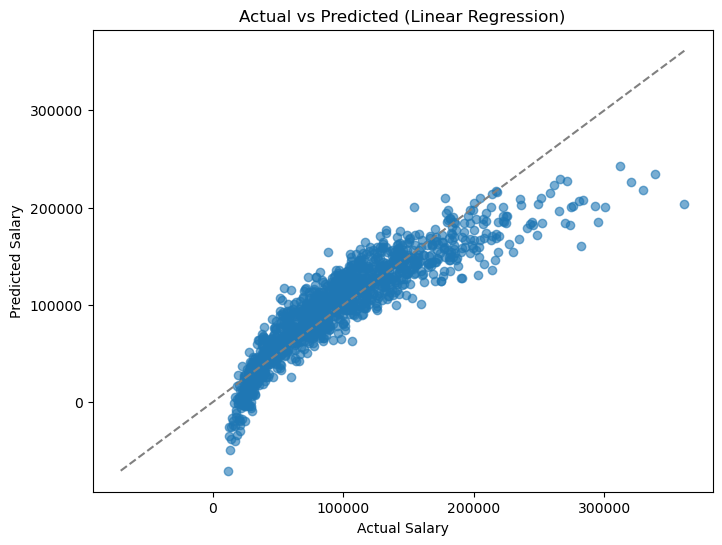

In [195]:
plot_actual_vs_predicted(y_test, y_pred_lr, "Linear Regression")

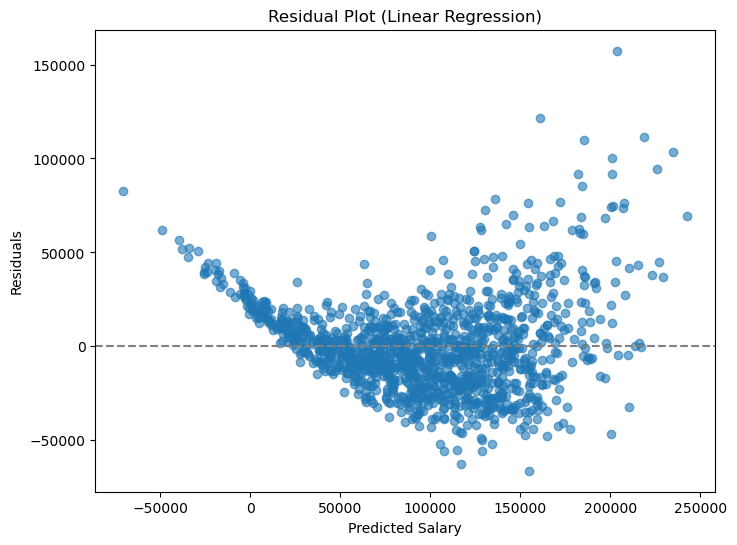

In [196]:
residuals_lr = plot_residuals(y_test, y_pred_lr, "Linear Regression")


### 4.5 Coefficients

In [197]:
coefficients_lr = pd.DataFrame({
    "Feature": feature_names_lr,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", ascending=False)

print(coefficients_lr.head(10))
print("\nIntercept:", lr_model.intercept_)


                                Feature   Coefficient
51  company_location_name_United States  50626.552560
19           experience_level_Executive  40586.859485
40      company_location_name_Australia  21673.880535
20                experience_level_Lead  21385.376004
42         company_location_name_Canada  17789.914343
25            employment_type_Full-time  16528.441662
33                     industry_Finance  16219.407364
12       job_title_Data Science Manager  15494.095243
14               job_title_LLM Engineer  15410.454586
55                  education_level_PhD  15036.015376

Intercept: 79430.90089598668


In [198]:
df_result = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred_lr
})

df_result.to_csv('prediction_results_LinearRegression.csv', index=False)

## 5. Model 2 — Polynomial Regression

### 5.1 Preprocessing

In [199]:
encoder_poly = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_poly = encoder_poly.fit_transform(X_train[categorical_cols])
X_test_cat_poly = encoder_poly.transform(X_test[categorical_cols])

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_num = poly.fit_transform(X_train[numerical_cols])
X_test_poly_num = poly.transform(X_test[numerical_cols])

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly_num)
X_test_poly_scaled = scaler_poly.transform(X_test_poly_num)

X_train_poly = np.hstack([X_train_poly_scaled, X_train_cat_poly])
X_test_poly = np.hstack([X_test_poly_scaled, X_test_cat_poly])

print("Processed X_train:", X_train_poly.shape)


Processed X_train: (3750, 86)


### 5.2 Training

In [200]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 5.3 Prediction & Evaluation

In [201]:
train_pred_poly = poly_model.predict(X_train_poly)
y_pred_poly = poly_model.predict(X_test_poly)

evaluate_model("Polynomial Regression", y_train, train_pred_poly, y_test, y_pred_poly)

Polynomial Regression
  R2 (train) : 0.8212
  R2 (test)  : 0.8098
  MAE        : 18,272.50
  MSE        : 601,243,151.81
  RMSE       : 24,520.26


{'R2_train': 0.8211775491953274,
 'R2_test': 0.8097923014206989,
 'MAE': 18272.504418745382,
 'MSE': 601243151.8128805,
 'RMSE': np.float64(24520.26002743202)}

### 5.4 Model Selection

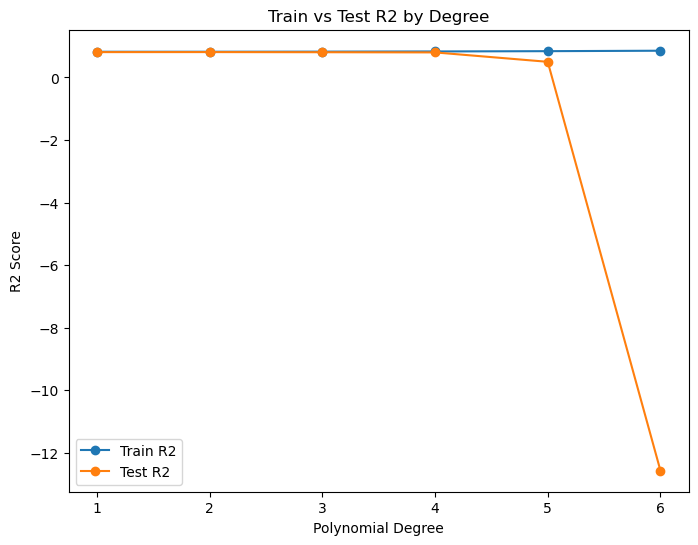

In [202]:
degrees = [1, 2, 3, 4, 5, 6]
train_scores_poly, test_scores_poly = [], []

for d in degrees:
    poly_d = PolynomialFeatures(degree=d, include_bias=False)
    X_train_d = poly_d.fit_transform(X_train[numerical_cols])
    X_test_d = poly_d.transform(X_test[numerical_cols])

    scaler_d = StandardScaler()
    X_train_d_scaled = scaler_d.fit_transform(X_train_d)
    X_test_d_scaled = scaler_d.transform(X_test_d)

    X_train_d_final = np.hstack([X_train_d_scaled, X_train_cat_poly])
    X_test_d_final = np.hstack([X_test_d_scaled, X_test_cat_poly])

    model_d = LinearRegression()
    model_d.fit(X_train_d_final, y_train)

    train_scores_poly.append(r2_score(y_train, model_d.predict(X_train_d_final)))
    test_scores_poly.append(r2_score(y_test, model_d.predict(X_test_d_final)))

plt.figure(figsize=(8, 6))
plt.plot(degrees, train_scores_poly, marker="o", label="Train R2")
plt.plot(degrees, test_scores_poly, marker="o", label="Test R2")
plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.title("Train vs Test R2 by Degree")
plt.legend()
plt.show()


### 5.5 Actual vs Predicted / Residuals

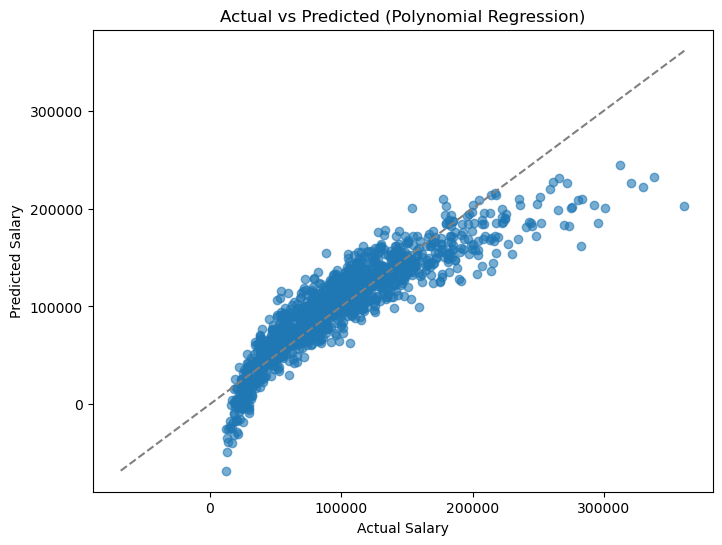

In [203]:
plot_actual_vs_predicted(y_test, y_pred_poly, "Polynomial Regression")


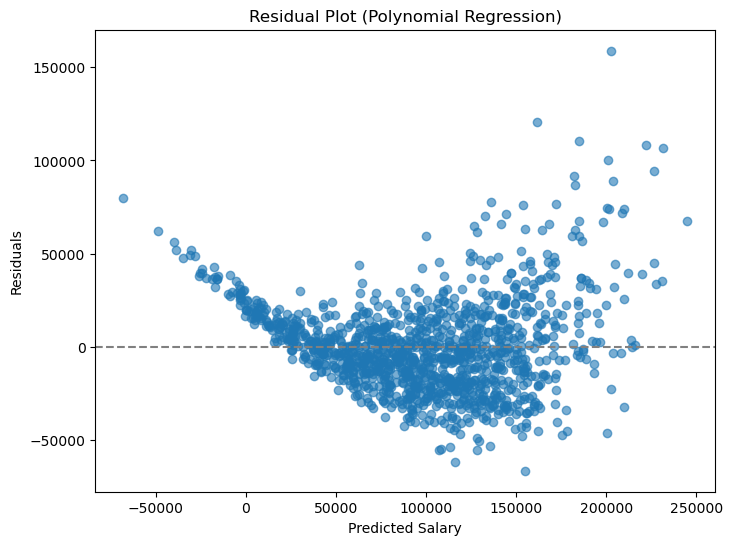

In [204]:
residuals_poly = plot_residuals(y_test, y_pred_poly, "Polynomial Regression")


In [205]:
df_result = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred_poly
})

df_result.to_csv('prediction_results_PolynomialRegression.csv', index=False)

## 6. Model 3 — Decision Tree Regressor

### 6.1 Preprocessing

In [206]:
encoder_dt = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_dt = encoder_dt.fit_transform(X_train[categorical_cols])
X_test_cat_dt = encoder_dt.transform(X_test[categorical_cols])

X_train_dt = np.hstack([X_train[numerical_cols].values, X_train_cat_dt])
X_test_dt = np.hstack([X_test[numerical_cols].values, X_test_cat_dt])

feature_names_dt = list(numerical_cols) + list(encoder_dt.get_feature_names_out(categorical_cols))

print("Processed X_train:", X_train_dt.shape)

Processed X_train: (3750, 65)


### 6.2 Building & Training

In [207]:
dtree = DecisionTreeRegressor(criterion='squared_error',max_depth=5, min_samples_split=2, min_samples_leaf=1, random_state=42)
dtree.fit(X_train_dt, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### 6.3 Prediction & Evaluation

In [208]:
train_pred_dt = dtree.predict(X_train_dt)
y_pred_dt = dtree.predict(X_test_dt)

evaluate_model("Decision Tree", y_train, train_pred_dt, y_test, y_pred_dt)

Decision Tree
  R2 (train) : 0.6812
  R2 (test)  : 0.6493
  MAE        : 23,671.35
  MSE        : 1,108,688,714.10
  RMSE       : 33,296.98


{'R2_train': 0.6811994790008569,
 'R2_test': 0.6492581610042665,
 'MAE': 23671.349202053254,
 'MSE': 1108688714.1033382,
 'RMSE': np.float64(33296.97755207428)}

### 6.4 Train vs Test R2 by Max Depth

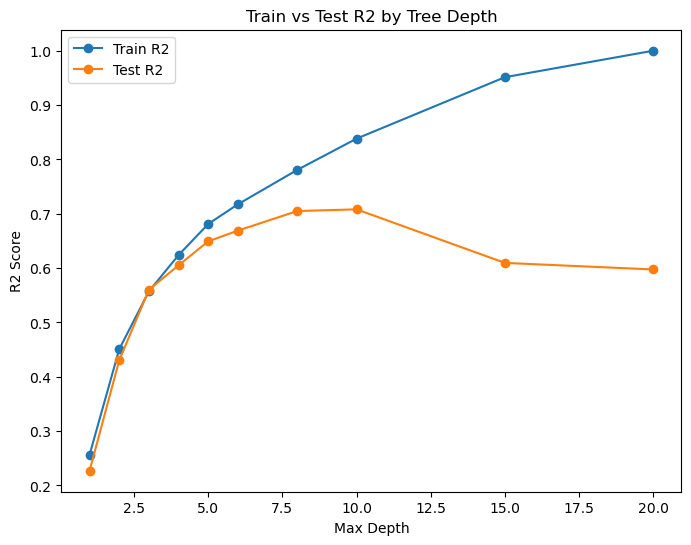

In [209]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
train_scores_dt, test_scores_dt = [], []

for d in depths:
    model_d = DecisionTreeRegressor(max_depth=d, random_state=42)
    model_d.fit(X_train_dt, y_train)
    train_scores_dt.append(r2_score(y_train, model_d.predict(X_train_dt)))
    test_scores_dt.append(r2_score(y_test, model_d.predict(X_test_dt)))

depths_labels = [d if d is not None else 20 for d in depths]
plt.figure(figsize=(8, 6))
plt.plot(depths_labels, train_scores_dt, marker="o", label="Train R2")
plt.plot(depths_labels, test_scores_dt, marker="o", label="Test R2")
plt.xlabel("Max Depth")
plt.ylabel("R2 Score")
plt.title("Train vs Test R2 by Tree Depth")
plt.legend()
plt.show()


### 6.5 Visualizing the Tree

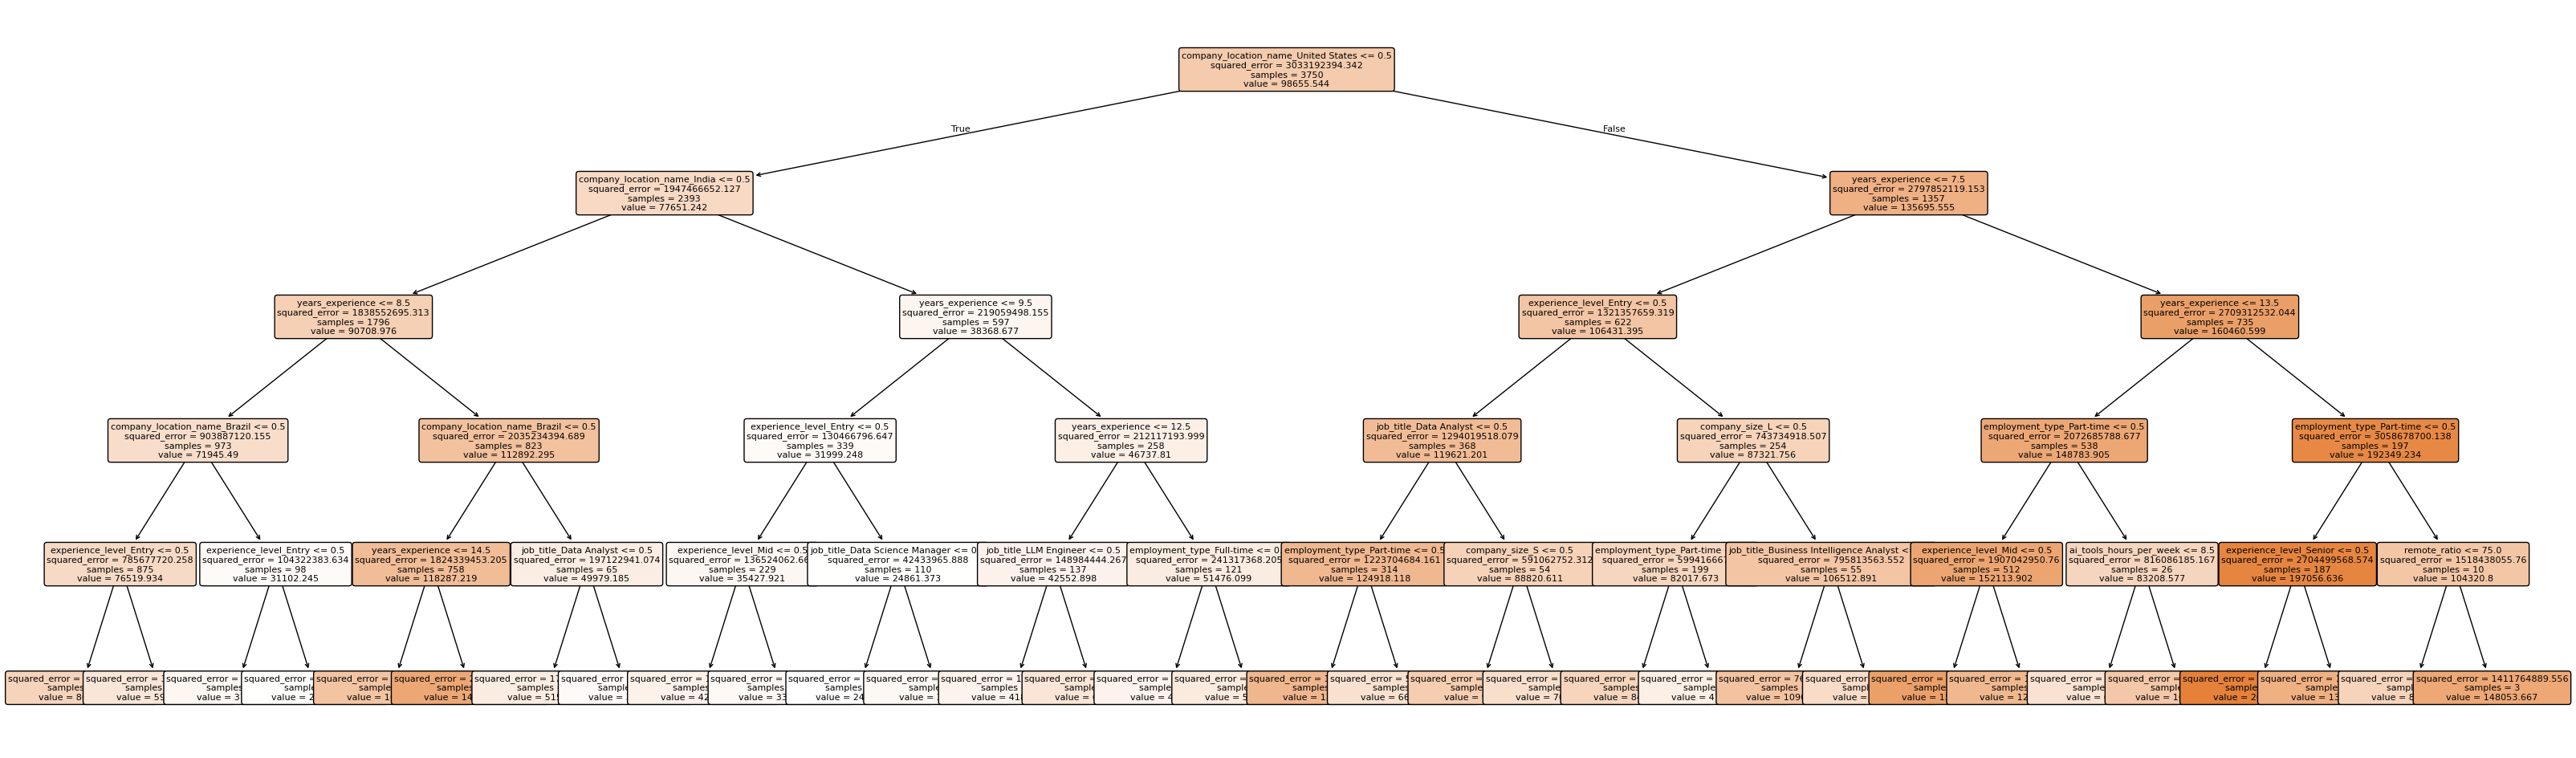

In [210]:
plt.figure(figsize=(40, 12))
plot_tree(dtree, feature_names=feature_names_dt, filled=True, rounded=True, fontsize=8)
plt.show()


### 6.6 Actual vs Predicted / Residuals

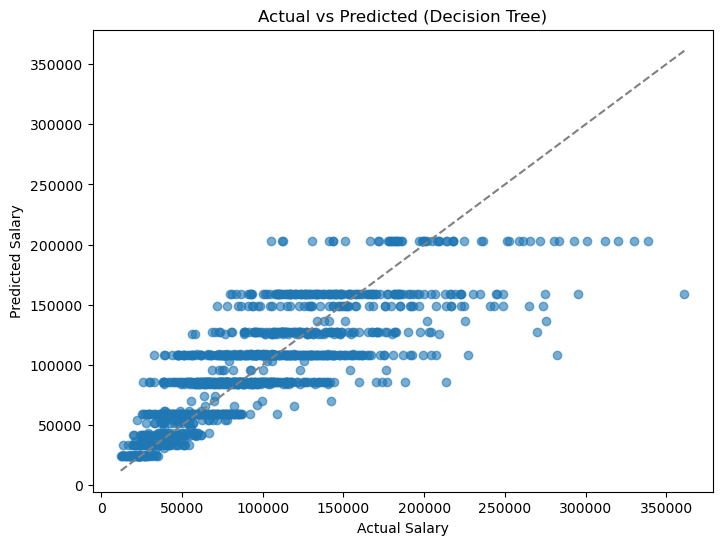

In [211]:
plot_actual_vs_predicted(y_test, y_pred_dt, "Decision Tree")


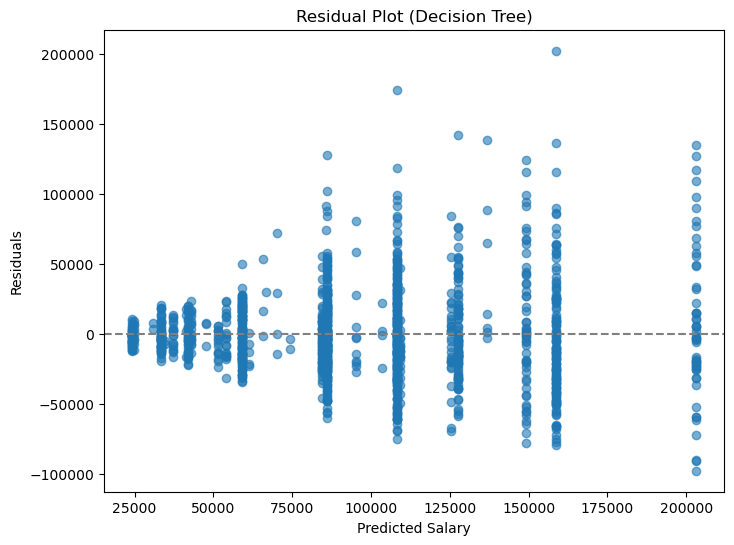

In [212]:
residuals_dt = plot_residuals(y_test, y_pred_dt, "Decision Tree")


### 6.7 Feature Importance

In [213]:
importances_dt = pd.DataFrame({
    "Feature": feature_names_dt,
    "Importance": dtree.feature_importances_
}).sort_values("Importance", ascending=False)

importances_dt.head(15)

,Feature,Importance
51,company_location_name_United States,0.376535
1,years_experience,0.293849
46,company_location_name_India,0.158418
41,company_location_name_Brazil,0.059513
18,experience_level_Entry,0.040647
26,employment_type_Part-time,0.034263
21,experience_level_Mid,0.012253
22,experience_level_Senior,0.008765
10,job_title_Data Analyst,0.008002
27,company_size_L,0.003337


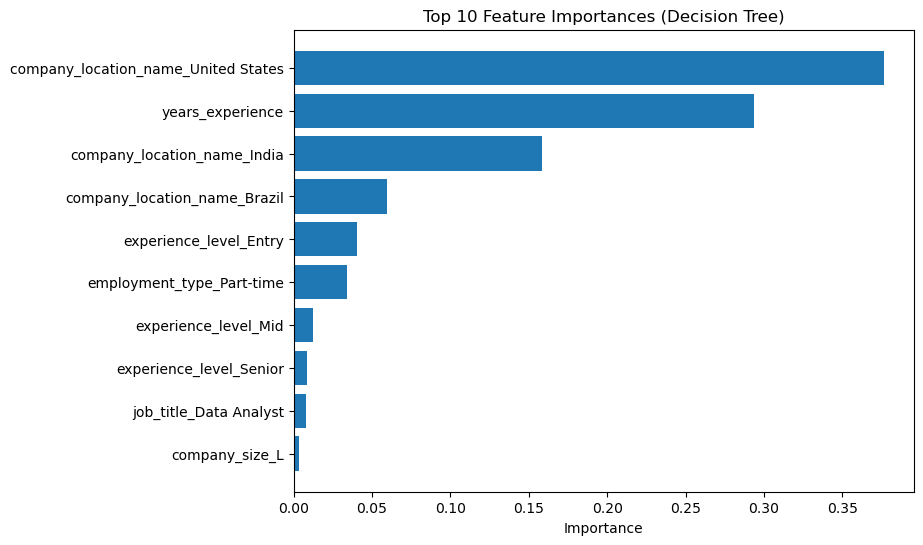

In [214]:
plot_feature_importance(importances_dt, "Decision Tree")


In [215]:
df_result = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred_dt
})

df_result.to_csv('prediction_results_DecisionTree.csv', index=False)

## 7. Model 4 — Random Forest Regressor

### 7.1 Preprocessing

In [216]:
encoder_rf = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_rf = encoder_rf.fit_transform(X_train[categorical_cols])
X_test_cat_rf = encoder_rf.transform(X_test[categorical_cols])

X_train_rf = np.hstack([X_train[numerical_cols].values, X_train_cat_rf])
X_test_rf = np.hstack([X_test[numerical_cols].values, X_test_cat_rf])

feature_names_rf = list(numerical_cols) + list(encoder_rf.get_feature_names_out(categorical_cols))

print("Processed X_train:", X_train_rf.shape)


Processed X_train: (3750, 65)


### 7.2 Building & Training

In [217]:
ranfor = RandomForestRegressor(
    n_estimators=300, max_depth=10, random_state=42, oob_score=True, n_jobs=-1
)
ranfor.fit(X_train_rf, y_train)

print("OOB Score:", ranfor.oob_score_)

OOB Score: 0.7816107980761048


c:\Users\Almagd\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)


### 7.3 Prediction & Evaluation

In [218]:
train_pred_rf = ranfor.predict(X_train_rf)
y_pred_rf = ranfor.predict(X_test_rf)

evaluate_model("Random Forest", y_train, train_pred_rf, y_test, y_pred_rf)


Random Forest
  R2 (train) : 0.8755
  R2 (test)  : 0.7760
  MAE        : 18,842.80
  MSE        : 708,120,652.33
  RMSE       : 26,610.54


{'R2_train': 0.8755209806488919,
 'R2_test': 0.7759808170963419,
 'MAE': 18842.80205652801,
 'MSE': 708120652.3267344,
 'RMSE': np.float64(26610.536490772494)}

### 7.4 Train vs Test R2 by Number of Trees

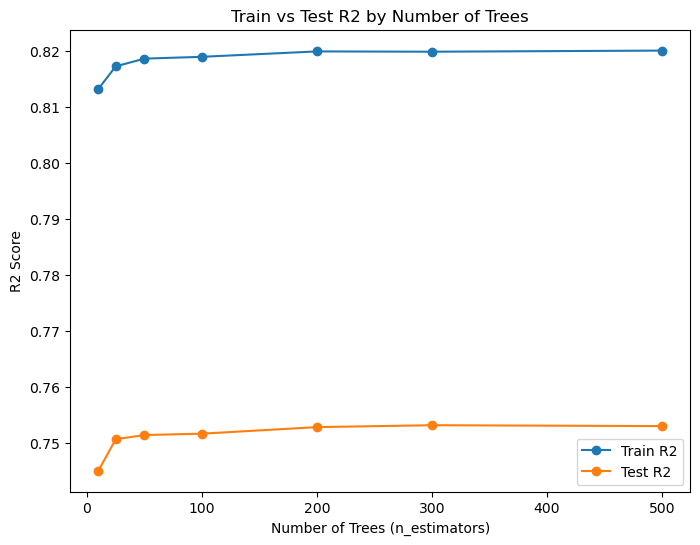

In [219]:
n_trees_list = [10, 25, 50, 100, 200, 300, 500]
train_scores_rf, test_scores_rf = [], []

for n in n_trees_list:
    model_n = RandomForestRegressor(n_estimators=n, max_depth=8, random_state=42, n_jobs=-1)
    model_n.fit(X_train_rf, y_train)
    train_scores_rf.append(r2_score(y_train, model_n.predict(X_train_rf)))
    test_scores_rf.append(r2_score(y_test, model_n.predict(X_test_rf)))

plt.figure(figsize=(8, 6))
plt.plot(n_trees_list, train_scores_rf, marker="o", label="Train R2")
plt.plot(n_trees_list, test_scores_rf, marker="o", label="Test R2")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("R2 Score")
plt.title("Train vs Test R2 by Number of Trees")
plt.legend()
plt.show()


### 7.5 Actual vs Predicted / Residuals

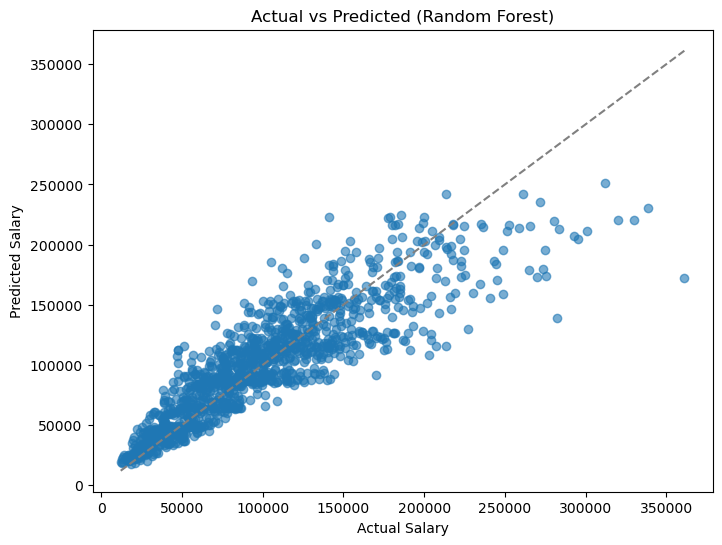

In [220]:
plot_actual_vs_predicted(y_test, y_pred_rf, "Random Forest")


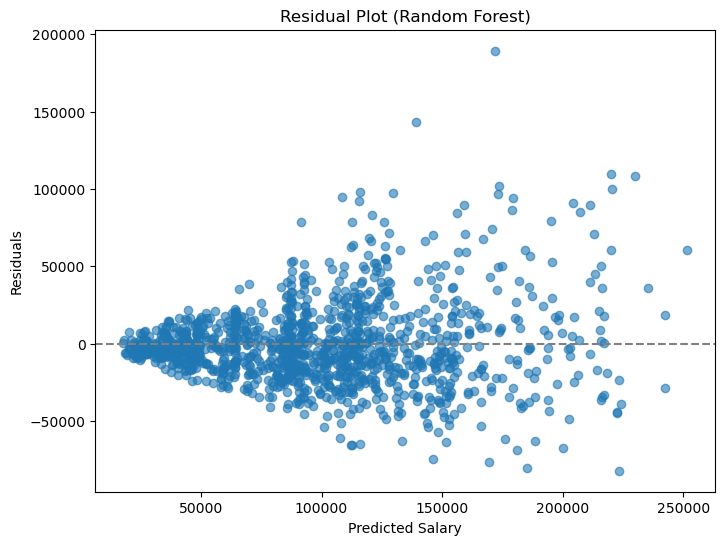

In [221]:
residuals_rf = plot_residuals(y_test, y_pred_rf, "Random Forest")


### 7.6 Feature Importance

In [222]:
importances_rf = pd.DataFrame({
    "Feature": feature_names_rf,
    "Importance": ranfor.feature_importances_
}).sort_values("Importance", ascending=False)

importances_rf.head(15)


,Feature,Importance
51,company_location_name_United States,0.291834
1,years_experience,0.232550
46,company_location_name_India,0.126816
41,company_location_name_Brazil,0.046006
18,experience_level_Entry,0.036126
26,employment_type_Part-time,0.030227
10,job_title_Data Analyst,0.028875
27,company_size_L,0.022604
21,experience_level_Mid,0.013692
22,experience_level_Senior,0.013177


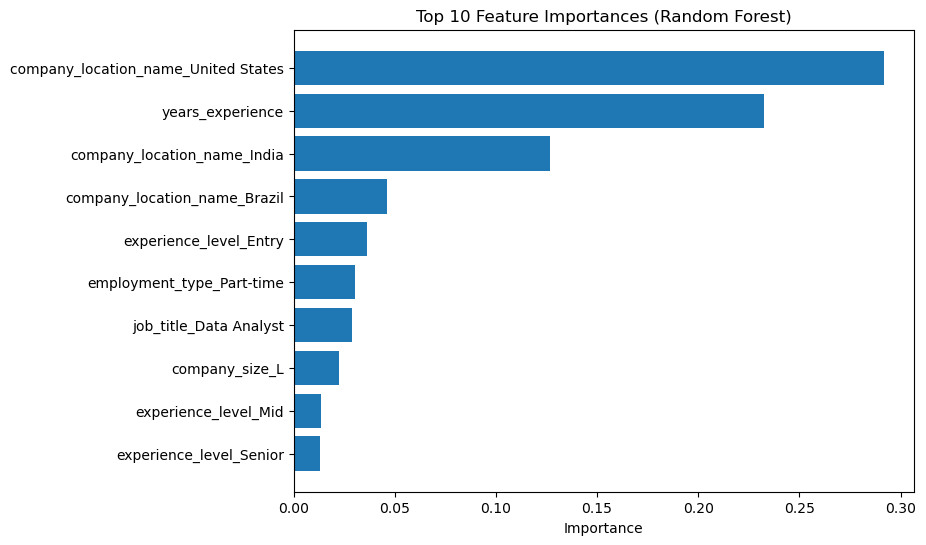

In [223]:
plot_feature_importance(importances_rf, "Random Forest")


In [224]:
df_result = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred_rf
})

df_result.to_csv('prediction_results_RandomForest.csv', index=False)

## 8. Model 5 — XGBoost

### 8.1 Preprocessing

In [225]:
encoder_xgb = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_xgb = encoder_xgb.fit_transform(X_train[categorical_cols])
X_test_cat_xgb = encoder_xgb.transform(X_test[categorical_cols])

X_train_xgb = np.hstack([X_train[numerical_cols].values, X_train_cat_xgb])
X_test_xgb = np.hstack([X_test[numerical_cols].values, X_test_cat_xgb])

feature_names_xgb = list(numerical_cols) + list(encoder_xgb.get_feature_names_out(categorical_cols))

X_train_final_xgb, X_val_xgb, y_train_final_xgb, y_val_xgb = train_test_split(
    X_train_xgb, y_train, test_size=0.15, random_state=42
)

print("Processed X_train:", X_train_xgb.shape)


Processed X_train: (3750, 65)


### 8.2 Building & Training

In [226]:
xgb_model = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    n_jobs=-1, early_stopping_rounds=20, eval_metric="rmse"
)

xgb_model.fit(
    X_train_final_xgb, y_train_final_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)], verbose=False
)

print("Best iteration:", xgb_model.best_iteration)


Best iteration: 499


### 8.3 Prediction & Evaluation

In [227]:
train_pred_xgb = xgb_model.predict(X_train_xgb)
y_pred_xgb = xgb_model.predict(X_test_xgb)

evaluate_model("XGBoost", y_train, train_pred_xgb, y_test, y_pred_xgb)


XGBoost
  R2 (train) : 0.8883
  R2 (test)  : 0.8455
  MAE        : 15,699.26
  MSE        : 488,483,328.00
  RMSE       : 22,101.66


{'R2_train': 0.8882623314857483,
 'R2_test': 0.8454647064208984,
 'MAE': 15699.2607421875,
 'MSE': 488483328.0,
 'RMSE': np.float64(22101.65894226042)}

### 8.4 Validation Curve

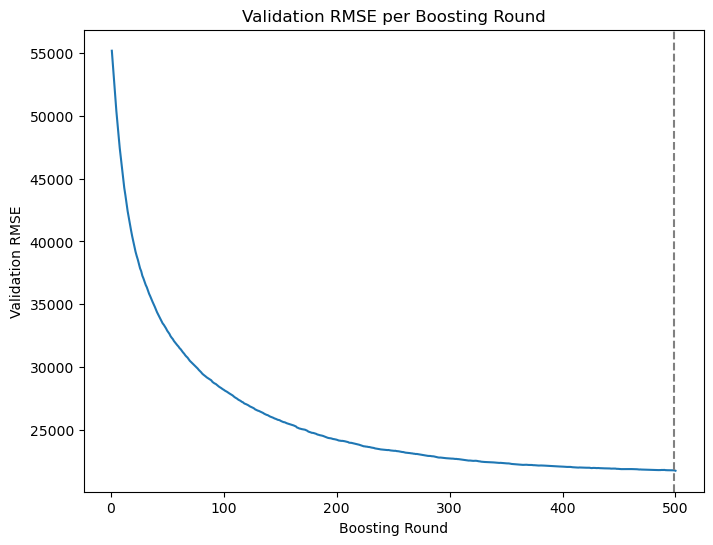

In [228]:
eval_results_xgb = xgb_model.evals_result()
val_rmse_xgb = eval_results_xgb["validation_0"]["rmse"]

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(val_rmse_xgb) + 1), val_rmse_xgb)
plt.axvline(xgb_model.best_iteration, linestyle="--", color="gray")
plt.xlabel("Boosting Round")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE per Boosting Round")
plt.show()


### 8.5 Actual vs Predicted / Residuals

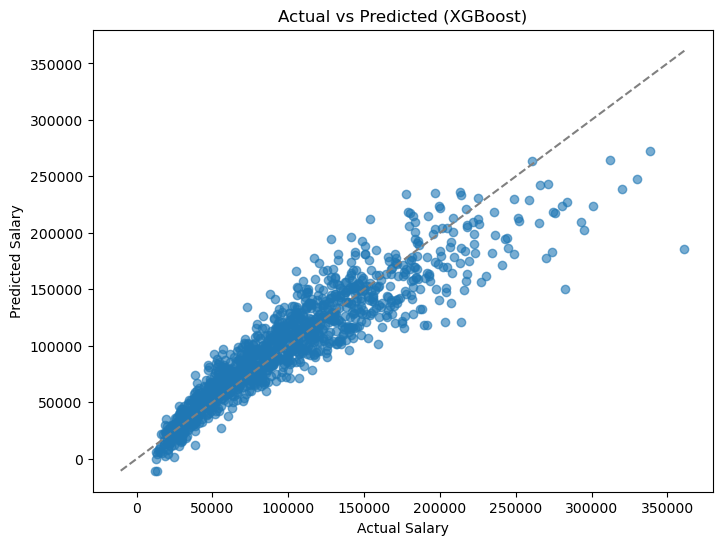

In [229]:
plot_actual_vs_predicted(y_test, y_pred_xgb, "XGBoost")


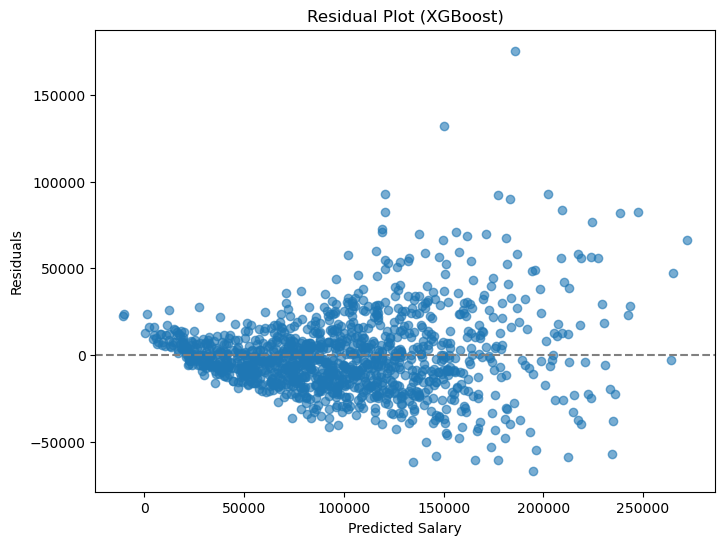

In [230]:
residuals_xgb = plot_residuals(y_test, y_pred_xgb, "XGBoost")


### 8.6 Feature Importance

<Figure size 800x600 with 0 Axes>

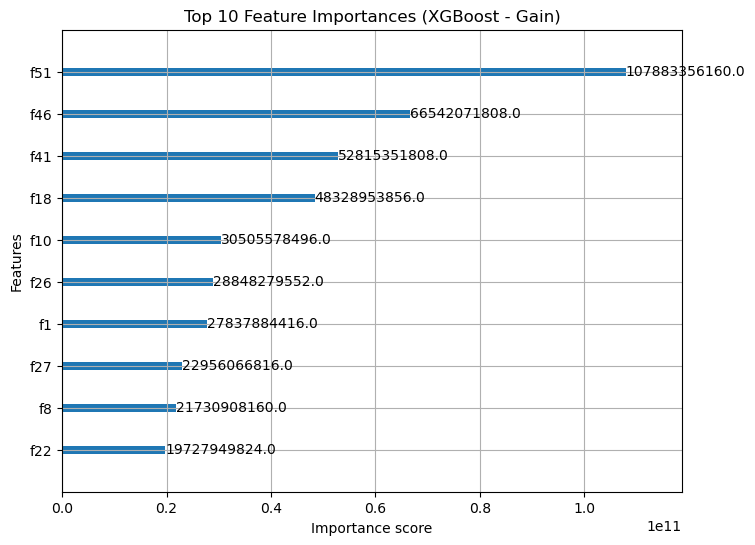

In [231]:
plt.figure(figsize=(8, 6))
plot_importance(xgb_model, max_num_features=10, importance_type="gain")
plt.title("Top 10 Feature Importances (XGBoost - Gain)")
plt.show()


In [232]:
importances_xgb = pd.DataFrame({
    "Feature": feature_names_xgb,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

importances_xgb.head(15)


,Feature,Importance
51,company_location_name_United States,0.151961
46,company_location_name_India,0.093729
41,company_location_name_Brazil,0.074394
18,experience_level_Entry,0.068075
10,job_title_Data Analyst,0.042969
26,employment_type_Part-time,0.040635
1,years_experience,0.039212
27,company_size_L,0.032335
8,job_title_Business Intelligence Analyst,0.030609
22,experience_level_Senior,0.027788


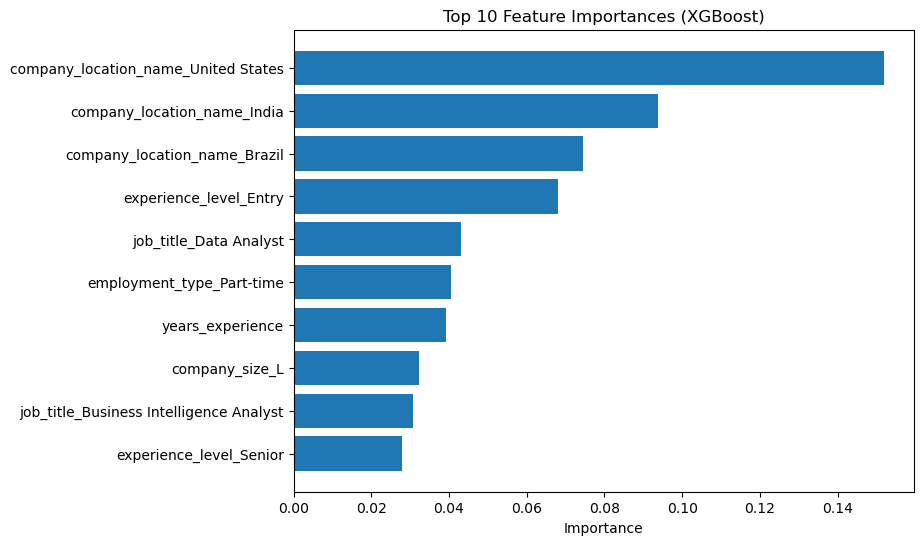

In [233]:
plot_feature_importance(importances_xgb, "XGBoost")


In [234]:
df_result = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred_xgb
})

df_result.to_csv('prediction_results_XGBoost.csv', index=False)

## 9. Model 6 & 7 — CatBoost & LightGBM

### 9.1 Validation Split

In [235]:
X_train_final_cb, X_val_cb, y_train_final_cb, y_val_cb = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)


### 9.2 Building & Training CatBoost

In [236]:
cb_model = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=6, cat_features=categorical_cols,
    l2_leaf_reg=3.0, early_stopping_rounds=30, random_state=42, verbose=False
)

start_time = time.time()
cb_model.fit(X_train_final_cb, y_train_final_cb, eval_set=(X_val_cb, y_val_cb), use_best_model=True)
print("CatBoost training time:", round(time.time() - start_time, 2), "seconds")


CatBoost training time: 15.87 seconds


### 9.3 Building & Training LightGBM

In [237]:
X_train_lgb = X_train_final_cb.copy()
X_val_lgb = X_val_cb.copy()
X_test_lgb = X_test.copy()

for col in categorical_cols:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_val_lgb[col] = X_val_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")

lgb_model = LGBMRegressor(
    n_estimators=200, learning_rate=0.05, num_leaves=31,
    min_child_samples=20, random_state=42, verbose=-1
)

start_time = time.time()
lgb_model.fit(
    X_train_lgb, y_train_final_cb,
    eval_set=[(X_val_lgb, y_val_cb)],
    callbacks=[early_stopping(stopping_rounds=30), log_evaluation(0)]
)
print("LightGBM training time:", round(time.time() - start_time, 2), "seconds")


Training until validation scores don't improve for 30 rounds


c:\Users\Almagd\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Did not meet early stopping. Best iteration is:
[190]	valid_0's l2: 4.38405e+08
LightGBM training time: 0.22 seconds


### 9.4 Prediction & Evaluation

In [238]:
train_pred_cb = cb_model.predict(X_train)
y_pred_cb = cb_model.predict(X_test)

train_pred_lgb = lgb_model.predict(X_train_lgb)
y_pred_lgb = lgb_model.predict(X_test_lgb)

evaluate_model("CatBoost", y_train, train_pred_cb, y_test, y_pred_cb)
print()
evaluate_model("LightGBM", y_train_final_cb, train_pred_lgb, y_test, y_pred_lgb)

CatBoost
  R2 (train) : 0.8880
  R2 (test)  : 0.8640
  MAE        : 14,654.33
  MSE        : 430,024,509.89
  RMSE       : 20,737.03

LightGBM
  R2 (train) : 0.9387
  R2 (test)  : 0.8554
  MAE        : 15,255.52
  MSE        : 457,192,699.82
  RMSE       : 21,382.06


{'R2_train': 0.9387004359745844,
 'R2_test': 0.8553637226826551,
 'MAE': 15255.518624123362,
 'MSE': 457192699.8239053,
 'RMSE': np.float64(21382.06491019764)}

### 9.5 Actual vs Predicted (Both Models)

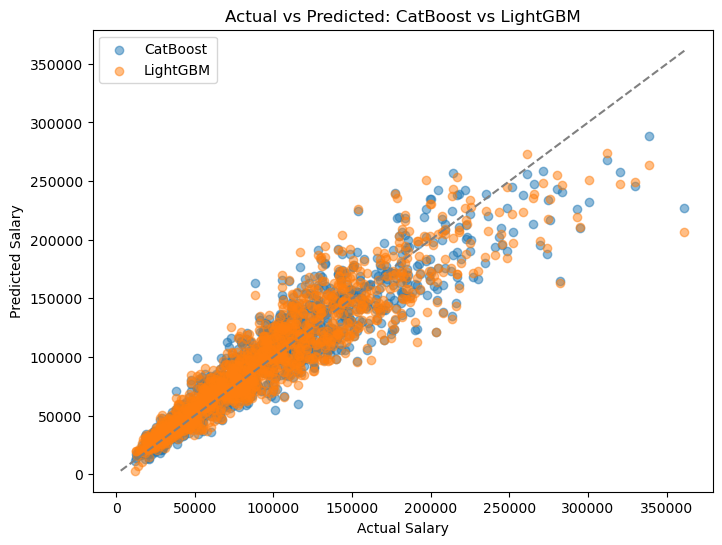

In [239]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_cb, alpha=0.5, label="CatBoost")
plt.scatter(y_test, y_pred_lgb, alpha=0.5, label="LightGBM")
min_v = min(y_test.min(), y_pred_cb.min(), y_pred_lgb.min())
max_v = max(y_test.max(), y_pred_cb.max(), y_pred_lgb.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--", color="gray")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted: CatBoost vs LightGBM")
plt.legend()
plt.show()


In [240]:
df_result = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred_cb
})

df_result.to_csv('prediction_results_CatBoost.csv', index=False)

In [241]:
df_result = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred_lgb
})

df_result.to_csv('prediction_results_LightGBM.csv', index=False)

## 10. Final Model Comparison

In [242]:
comparison_df = pd.DataFrame(results).T.sort_values("RMSE")
comparison_df

,R2_train,R2_test,MAE,MSE,RMSE
CatBoost,0.888047,0.863959,14654.325263,4.300245e+08,20737.032331
LightGBM,0.938700,0.855364,15255.518624,4.571927e+08,21382.064910
XGBoost,0.888262,0.845465,15699.260742,4.884833e+08,22101.658942
Polynomial Regression,0.821178,0.809792,18272.504419,6.012432e+08,24520.260027
Linear Regression,0.820493,0.808857,18300.670496,6.041998e+08,24580.475695
Random Forest,0.875521,0.775981,18842.802057,7.081207e+08,26610.536491
Decision Tree,0.681199,0.649258,23671.349202,1.108689e+09,33296.977552


### 10.1 RMSE Comparison (lower is better)

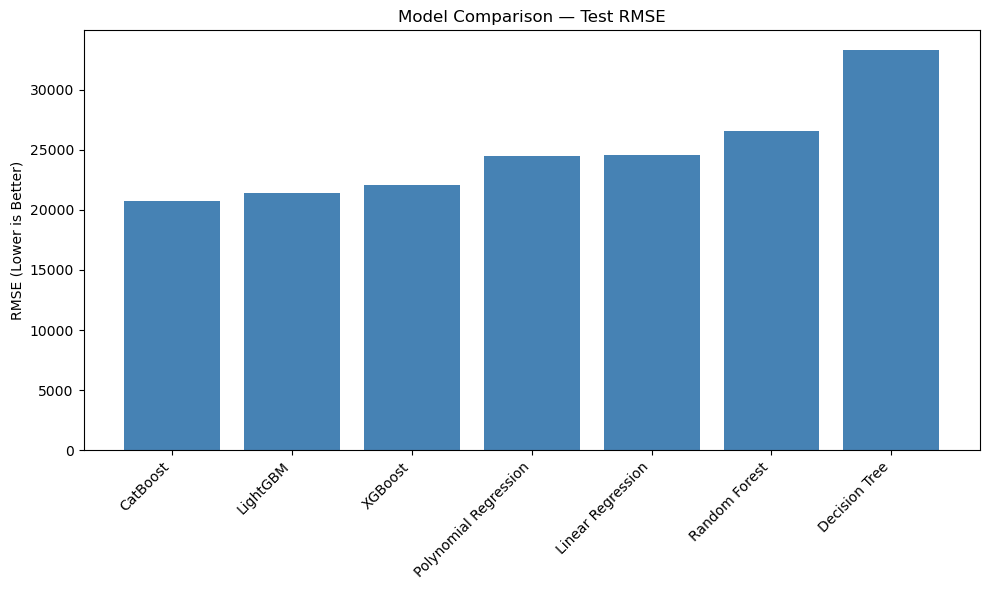

In [243]:
plt.figure(figsize=(10, 6))
plt.bar(comparison_df.index, comparison_df["RMSE"], color="steelblue")
plt.ylabel("RMSE (Lower is Better)")
plt.title("Model Comparison — Test RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 10.2 R² Comparison (higher is better)

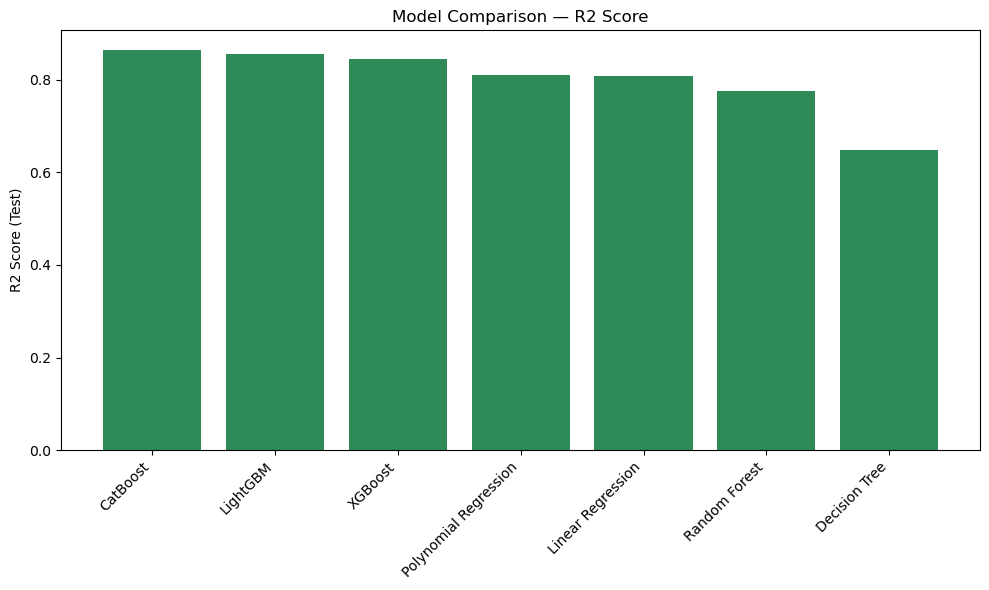

In [244]:
plt.figure(figsize=(10, 6))
plt.bar(comparison_df.index, comparison_df["R2_test"], color="seagreen")
plt.ylabel("R2 Score (Test)")
plt.title("Model Comparison — R2 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
